**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  

To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. 

You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [247]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from plotly import express as px

In [248]:
data_canada = px.data.gapminder().query("country == 'Canada'")
fig = px.bar(data_canada, x='year', y='pop')

### Problems

#### Use the prompts below to get started with your data analysis.  

### 1. Read in the `coupons.csv` file.




In [249]:
data = pd.read_csv('data/coupons.csv')

In [250]:
#data.head(4)

### 2. Investigate the dataset for missing or problematic data.

In [251]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

In [252]:
data.shape

(12684, 26)

**Checking for Nan values**

In [253]:
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

 **Replace all Nans with ''.**

In [254]:
data['car'] = data['car'].fillna('')
data['Bar'] = data['Bar'].fillna('')
data['CoffeeHouse'] = data['CoffeeHouse'].fillna('')
data['CarryAway'] = data['CarryAway'].fillna('')
data['RestaurantLessThan20'] = data['RestaurantLessThan20'].fillna('')
data['Restaurant20To50'] = data['Restaurant20To50'].fillna('')

In [255]:
data.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

### 3. Decide what to do about your missing data -- drop, replace, other...

**Car**

In [256]:
data['car'].unique()

<ArrowStringArray>
[                                        '',
                   'Scooter and motorcycle',
                                'crossover',
                                   'Mazda5',
                             'do not drive',
 'Car that is too old to install Onstar :D']
Length: 6, dtype: str

In [257]:
len(data[data['car'] != ''])

108

In [258]:
len(data[data['car'] != ''])/len(data) * 100

0.8514664143803218

The Car column is less than 1 percent of the data, but it is interesting. Perhaps is we isolate the labeled cars we might see that folks that 'do not drive' or use 'Scooter and motercle' may be more amenable to using a coupon.  
**Keep the Car data**

#### Duplicate Rows

In [259]:
len(data[data.duplicated() == True])

74

In [260]:
74/12684 * 100

0.5834121728161463

74 of the 12684 rows are duplicates. Its unclear if these are problems with the data or if the two individual of the same profile were surveyed at the same time. Given the time is a rough measure of time - no minutes or seconds - is it possible that more than one person who met the same profile were surveyed. Perhaps they were together? Even if they are duplicates they represent 0.6 percent of the data, so we will keep them in.

**Keep duplicate lines.**

### 4. What proportion of the total observations chose to accept the coupon?

In [261]:
len_data = len(data)
len_data

12684

In [262]:
Y_len  = len(data[data['Y'] == 1])
Y_len

7210

In [263]:
Y_len / len_data * 100

56.84326710816777

**57 percent of the observations accepted the coupon**

### 5. Use a bar plot to visualize the `coupon` column.

In [264]:
coupons = data["coupon"].value_counts()

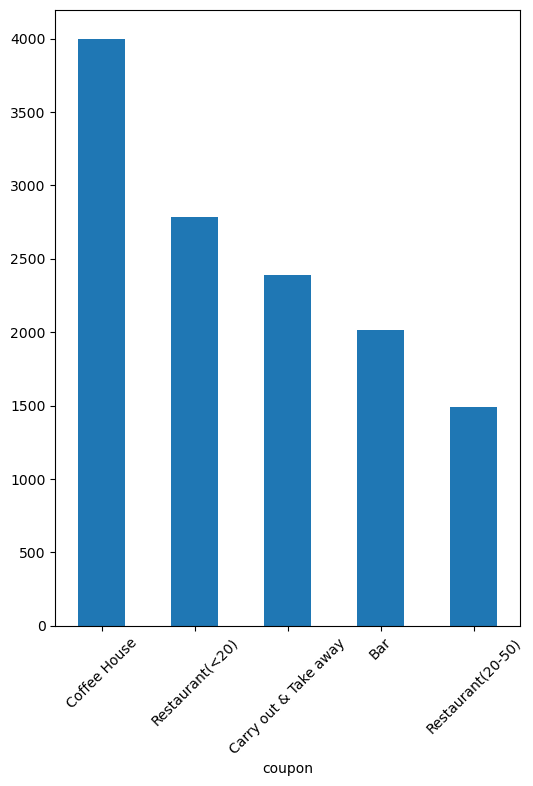

In [265]:
coupons.plot(kind="bar",rot=45)
plt.rcParams["figure.figsize"] = (6, 8) # (width, height) in inches

plt.savefig("images/total_yes.png")

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant(<20)'),
  Text(1, 0, 'Coffee House'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

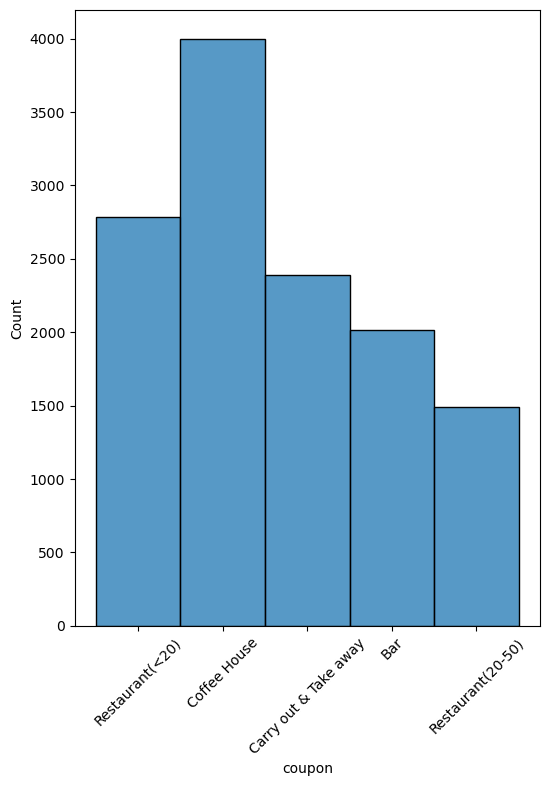

In [266]:
sns.histplot(data=data,x='coupon')
plt.xticks(rotation=45)

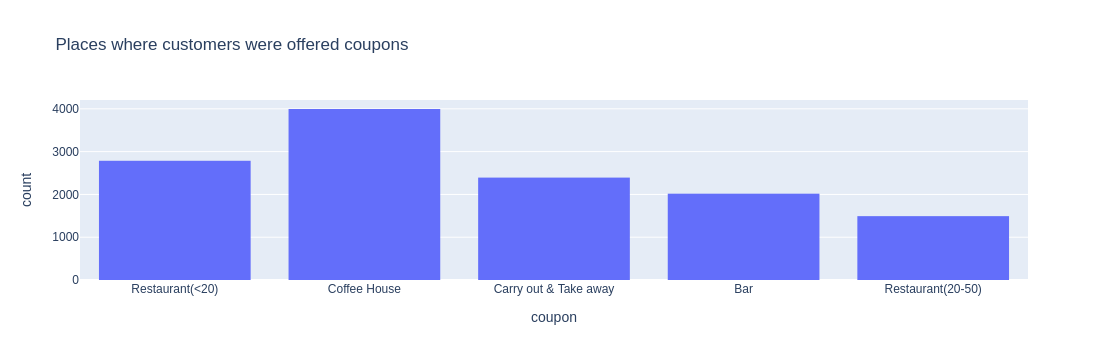

In [267]:
fig = px.histogram(data, x="coupon", title="Places where customers were offered coupons")     
fig.write_image("images/all_yes.png")
fig.show()


### 6. Use a histogram to visualize the temperature column.

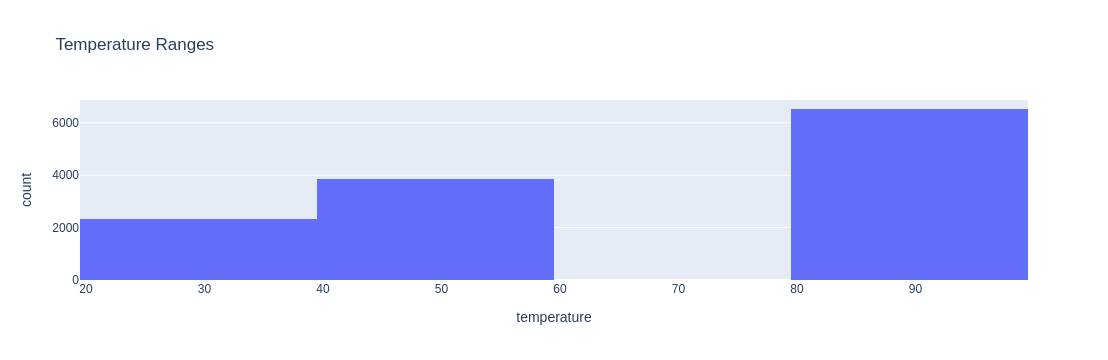

In [268]:
fig = px.histogram(data, x="temperature", title="Temperature Ranges")                
fig.show()
fig.write_image("images/temperature.png")

(array([20., 30., 40., 50., 60., 70., 80., 90.]),
 [Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80'),
  Text(90.0, 0, '90')])

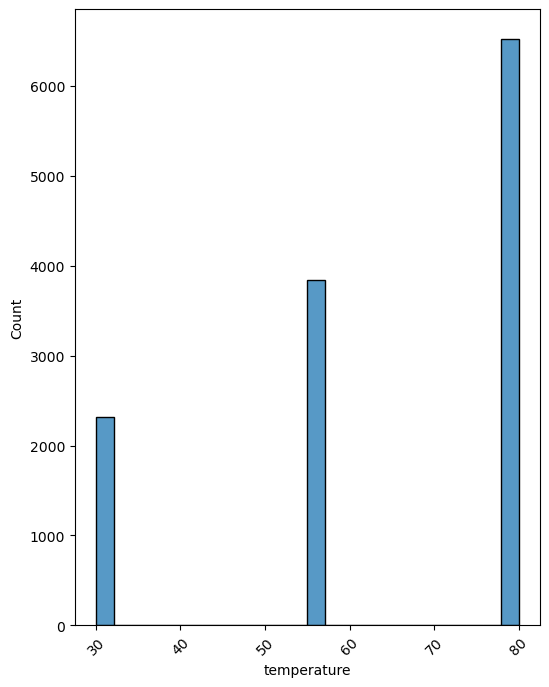

In [269]:
sns.histplot(data=data,x='temperature')
plt.xticks(rotation=45)

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

### 1. Create a new `DataFrame` that contains just the bar coupons.


In [270]:
bardf = data[['Bar']]

### 2. What proportion of bar coupons were accepted?


In [271]:
bar_df = data[data['coupon'] == 'Bar']
len(bar_df)

2017

In [272]:
bar_yes = data[(data['Y'] == 1) & (data['coupon'] == 'Bar')]
len(bar_yes)

827

In [273]:
len(bar_yes)/len(bar_df)

0.41001487357461575

**41 percent of individuals in the Bar used the coupon**

### 3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [274]:
data['Bar'].unique()

<ArrowStringArray>
['never', 'less1', '1~3', 'gt8', '', '4~8']
Length: 6, dtype: str

In [275]:
# three or fewer times a month
bar_lte3_df = data[(data['Bar'] == 'less1') | (data['Bar'] == '1~3')]
bar_lte3_len = len(bar_lte3_df)
bar_lte3_len

5955

In [276]:
# three or fewer times a month yes
y_bar_lte3_df = bar_lte3_df[bar_lte3_df['Y'] == 1]
y_bar_lte3_df_len = len(y_bar_lte3_df)
y_bar_lte3_df_len

3501

In [277]:
# greater than 3 times a month
bar_gt3_df = data[ (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
bar_gt3_len = len(bar_gt3_df)
bar_gt3_len

1425

In [278]:
# greater than three times a month - yes
Y_bar_gt3_df = bar_gt3_df[bar_gt3_df['Y'] == 1]
Y_bar_gt3_len = len(Y_bar_gt3_df)
Y_bar_gt3_len

887

In [279]:
y_bar_lte3_df_len/bar_lte3_len  * 100 # 58 percent of those who go to the bar less than three times a month accepted the coupon

58.79093198992443

In [280]:
Y_bar_gt3_len/bar_gt3_len * 100 # 62 percent of those who go to the bar more than three times a month accept the coupon

62.24561403508771

In [281]:
bar_lte3_len/bar_gt3_len # over four times a many people go the bar less than three times a month than those who
# go more than three times a month. But the greater than three days a month group are 62 percent likely to say yes 
# than the 58 percent of those who come less than three days a month

4.178947368421053

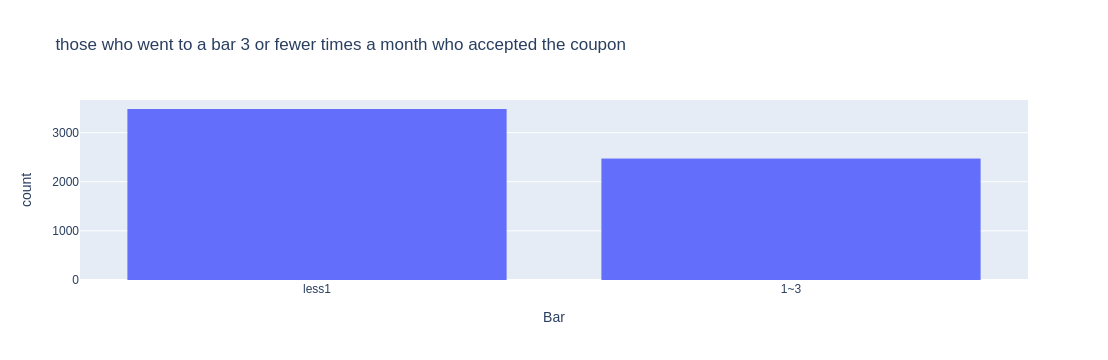

In [282]:

fig = px.histogram(bar_lte3_df, x="Bar",  title="those who went to a bar 3 or fewer times a month who accepted the coupon")
fig.write_image("images/bar_lt3_y.png")
fig.show()

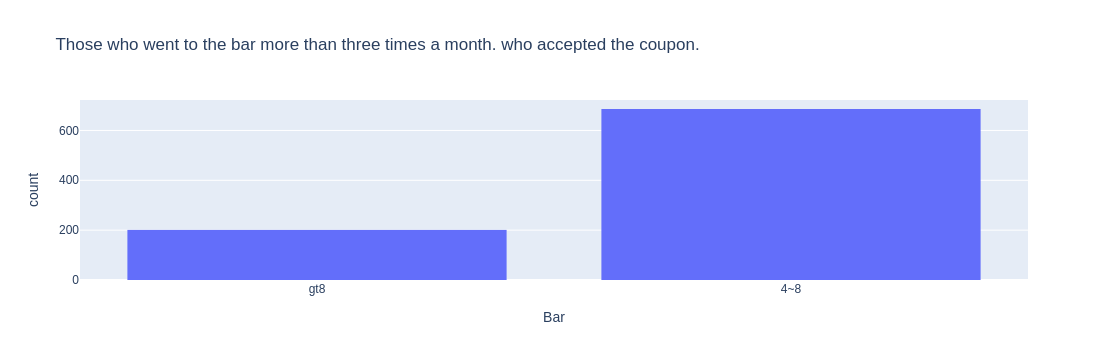

In [283]:
fig = px.histogram(Y_bar_gt3_df, x="Bar", title="Those who went to the bar more than three times a month. who accepted the coupon.")                
fig.show()
fig.write_image("images/bar_less_three.png")

Those who went to the bar three or less times a month used the coupon nearly four times more than those who went to the bar greater than three times a month. Those who went to the bar three or less times a month were 3501. Those more than three were 887. The ration is 3501/887 == 3.947012401352875

### 4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


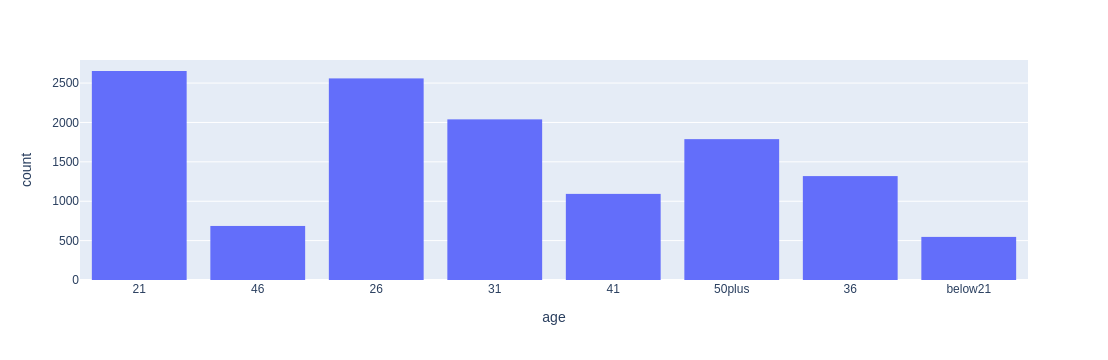

In [284]:
fig = px.histogram(data, x="age")                
fig.show()
fig.write_image("images/bar_greater_than_three.png")

In [285]:
cardf = data[data['car'] != 'do not drive'] # remove 'do not drive'

In [286]:
cardf['car'].unique()

<ArrowStringArray>
[                                        '',
                   'Scooter and motorcycle',
                                'crossover',
                                   'Mazda5',
 'Car that is too old to install Onstar :D']
Length: 5, dtype: str

In [287]:
car_g1_month_df = cardf[ (cardf['Bar'] == '1~3') | (cardf['Bar'] == '4~8') | (cardf['Bar'] == 'gt8')]
car_f1_month_len = len(car_g1_month_df)

In [288]:
car_g1_month_df['age'].unique()

<ArrowStringArray>
['21', '26', '31', '50plus', '41', '36', '46', 'below21']
Length: 8, dtype: str

In [289]:
car_g1m_g25_df = car_g1_month_df[(car_g1_month_df['age'] != '21') & (car_g1_month_df['age'] != 'below21')]
car_g1m_g25_len = len(car_g1m_g25_df)
car_g1m_g25_df['age'].unique()

<ArrowStringArray>
['26', '31', '50plus', '41', '36', '46']
Length: 6, dtype: str

In [290]:
car_g1m_g25_len # drivers greater than once a month. greater than 25 years old

2755

In [291]:
#g1m_g25['Y'] = g1m_g25['Y'].astype(int)

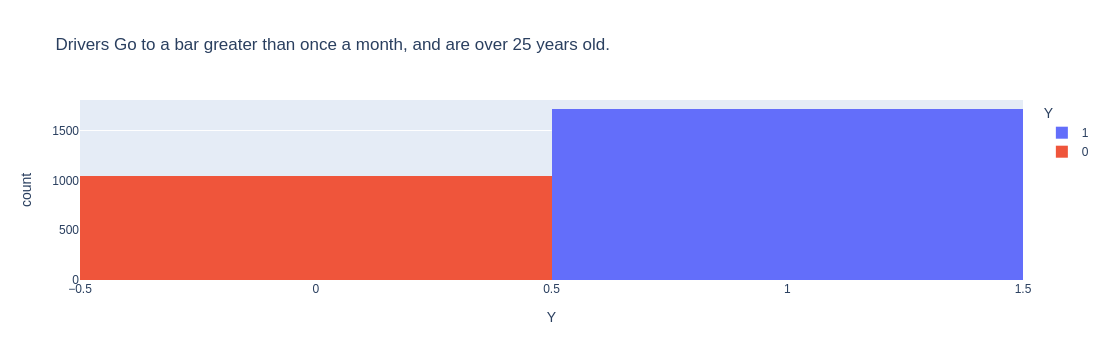

In [292]:
fig = px.histogram(car_g1m_g25_df, x="Y", title="Drivers Go to a bar greater than once a month, and are over 25 years old.", color="Y")                
fig.show()
fig.write_image("images/drivers_more_than_once_over25.png")

In [293]:
lesthan_1_month_df = data[ (data['Bar'] == 'less1')] # keep the 'do not drive' people
lesthan_1_month_len = len(lesthan_1_month_df) # bar less than once a month)
lesthan_1_month_len

3482

In [294]:
lt1m_lt25_df = lesthan_1_month_df[(lesthan_1_month_df['age'] == '21') | (lesthan_1_month_df['age'] == 'below21')]
lt1m_lt25_len = len(lt1m_lt25_df)

In [295]:
lt1m_lt25_df ['Bar'].unique() # goes less than once a month

<ArrowStringArray>
['less1']
Length: 1, dtype: str

In [296]:
lt1m_lt25_df ['age'].unique()

<ArrowStringArray>
['21', 'below21']
Length: 2, dtype: str

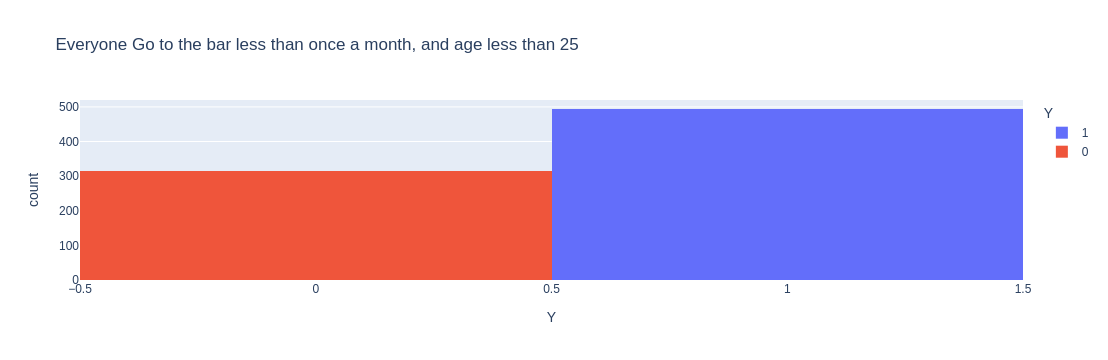

In [297]:
fig = px.histogram(lt1m_lt25_df, x="Y", title="Everyone Go to the bar less than once a month, and age less than 25", color="Y" )                
fig.show()
fig.write_image("images/all_less_than_once_less25.png")

In [298]:
len(car_g1m_g25_df[car_g1m_g25_df['Y'] == 1]) # drivers go to the bar greater than once a month over 25 and use a coupon

1716

In [299]:
len(car_g1m_g25_df)

2755

In [300]:
len(car_g1m_g25_df[car_g1m_g25_df['Y'] == 1]) /len(car_g1m_g25_df)

0.6228675136116153

In [301]:
len(lt1m_lt25_df[lt1m_lt25_df['Y'] == 1]) # go to the bar less than once a month, and under 25 and accept coupon

494

In [302]:
len(lt1m_lt25_df) #all go to the bar less than once a month, and under 25 

808

In [303]:
len(lt1m_lt25_df[lt1m_lt25_df['Y'] == 1]) / len(lt1m_lt25_df)

0.6113861386138614

In [304]:
len(car_g1m_g25_df) / len(lt1m_lt25_df) # 3.4 drivers > once a month and >25 / all < once a mont and < 25 year old 

3.4096534653465347

Although there are 3.4 times as many drivers who are over 25 and go to the bar more than once a month than those who are under 25 and go to the bar less than once a month, the percentage of those who use coupone is 62% and 61% respectively. So there does not seem to be a difference between these two groups.

#### 5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [305]:
cardf = data[data['car'] != 'do not drive'] # remove 'do not drive'

In [306]:
morethan_1_monthdf = cardf[ (cardf['Bar'] == '1~3') | (cardf['Bar'] == '4~8') | (cardf['Bar'] == 'gt8')]
morethan_1_month_len = len(morethan_1_monthdf)
morethan_1_monthdf['Bar'].unique()

<ArrowStringArray>
['1~3', 'gt8', '4~8']
Length: 3, dtype: str

In [307]:
morethan_1_monthdf['passanger'].unique()

<ArrowStringArray>
['Alone', 'Friend(s)', 'Partner', 'Kid(s)']
Length: 4, dtype: str

In [308]:
g1m_pnk_df = morethan_1_monthdf[(morethan_1_monthdf["passanger"]!= "Kid(s)") & (morethan_1_monthdf["passanger"]!= "Alone")]

In [309]:
g1m_pnk_df['passanger'].unique()

<ArrowStringArray>
['Friend(s)', 'Partner']
Length: 2, dtype: str

In [310]:
morethan_1_monthdf["occupation"].unique() 
# There are no Farming Fishing or Forestry customers who come to the bar more than once a month.

<ArrowStringArray>
[                                  'Student',
                        'Healthcare Support',
                                'Management',
                                'Unemployed',
                           'Sales & Related',
           'Office & Administrative Support',
                 'Construction & Extraction',
                                     'Legal',
              'Life Physical Social Science',
                                   'Retired',
                   'Computer & Mathematical',
      'Healthcare Practitioners & Technical',
                   'Personal Care & Service',
                'Architecture & Engineering',
  'Arts Design Entertainment Sports & Media',
                        'Protective Service',
                      'Business & Financial',
        'Food Preparation & Serving Related',
         'Installation Maintenance & Repair',
                'Education&Training&Library',
               'Community & Social Services',
               

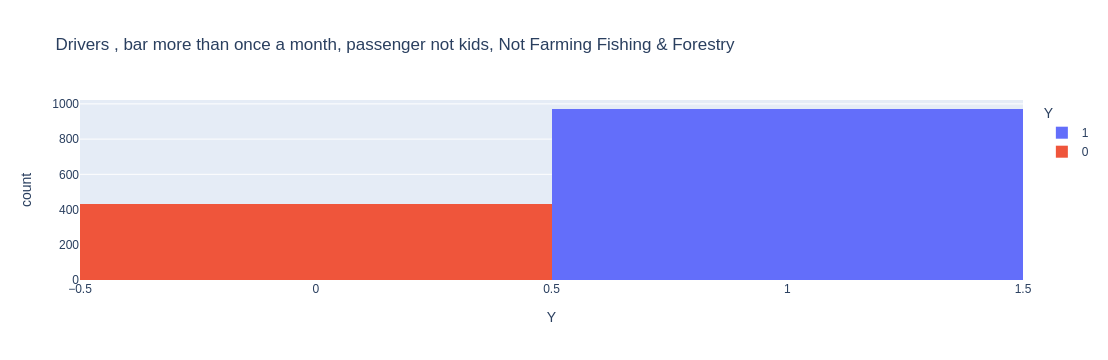

In [311]:
fig = px.histogram(g1m_pnk_df, x="Y",title="Drivers , bar more than once a month, passenger not kids, Not Farming Fishing & Forestry", color="Y")
fig.show()
fig.write_image("images/drivers_more_than_once_no_kids.png")

In [312]:
glm_pnk_len = len(g1m_pnk_df) # all who go to the bar more than once a month, passengers are not kids

In [313]:
g1m_pnk_Y_len = len(g1m_pnk_df[g1m_pnk_df['Y'] == 1])
g1m_pnk_Y_len

971

In [314]:
g1m_pnk_Y_len/glm_pnk_len * 100

69.11032028469751

Sixty-nine percent of the population who drive, go more than once a month, have passengers that are not kids, and are not farming, fishing or forestry chose to use coupons. There are no Farming, Fishing nor Forestry people among those who come to the bar greater than once a month and have customers that are not kids, so this is not relevant.

### 6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [315]:
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='str')

In [316]:
g1m_pnk_df['Bar'].unique()

<ArrowStringArray>
['1~3', 'gt8', '4~8']
Length: 3, dtype: str

In [317]:
g1m_pnk_df['passanger'].unique()

<ArrowStringArray>
['Friend(s)', 'Partner']
Length: 2, dtype: str

In [318]:
g1m_pnk_df['maritalStatus'].unique()

<ArrowStringArray>
['Single', 'Unmarried partner', 'Married partner', 'Divorced']
Length: 4, dtype: str

#### drivers bar greater than once a month with non kid passangeres are not widowed.

In [319]:
morethan_1_month = cardf[ (cardf['Bar'] == '1~3') | (cardf['Bar'] == '4~8') | (cardf['Bar'] == 'gt8')]
morethan_1_month['Bar'].unique()

<ArrowStringArray>
['1~3', 'gt8', '4~8']
Length: 3, dtype: str

In [320]:
morethan_1_month['age'].unique()

<ArrowStringArray>
['21', '26', '31', '50plus', '41', '36', '46', 'below21']
Length: 8, dtype: str

In [321]:
morethan_1_month['passanger'].unique()

<ArrowStringArray>
['Alone', 'Friend(s)', 'Partner', 'Kid(s)']
Length: 4, dtype: str

In [322]:
g1m_nk_df = morethan_1_month[morethan_1_month['passanger'] != 'Kid(s)']

In [323]:
g1m_nk_df['passanger'].unique()

<ArrowStringArray>
['Alone', 'Friend(s)', 'Partner']
Length: 3, dtype: str

In [324]:
g1m_nk_df['maritalStatus'].unique()

<ArrowStringArray>
['Single', 'Unmarried partner', 'Married partner', 'Divorced']
Length: 4, dtype: str

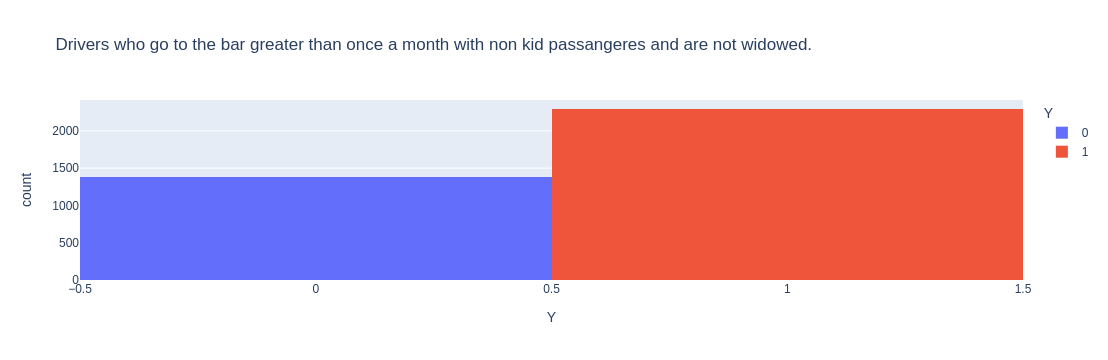

In [325]:
fig = px.histogram(g1m_nk_df, x="Y", title="Drivers who go to the bar greater than once a month with non kid passangeres and are not widowed.", color="Y")                
fig.show()
fig.write_image("images/drivers_more_than_once_no_kids_not_widowed.png")

In [326]:
m1m_lt30_df = morethan_1_month[morethan_1_month['age'].isin(["26", "21", "below21"])]
m1m_lt30_df['age'].unique()

<ArrowStringArray>
['21', '26', 'below21']
Length: 3, dtype: str

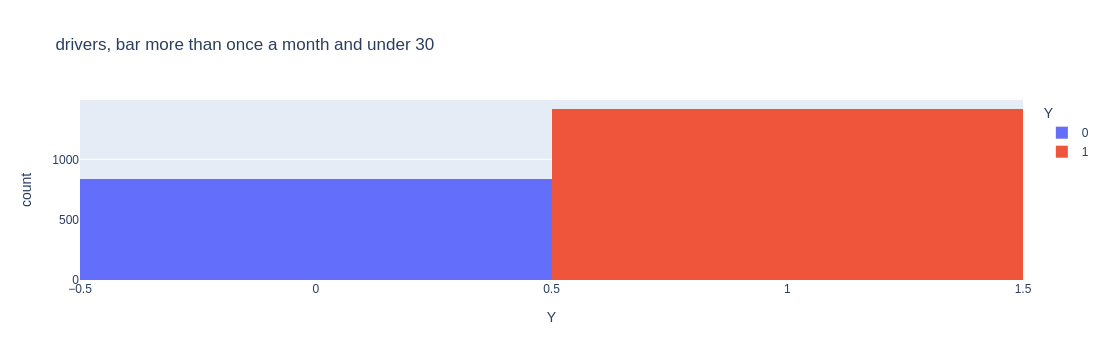

In [327]:
fig = px.histogram(m1m_lt30_df, x="Y", title="drivers, bar more than once a month and under 30", color="Y")                
fig.show()
fig.write_image("images/drivers_more_than_once_under_30.png")

In [328]:
m1m_lt30_len = len(m1m_lt30_df)
m1m_lt30_len

2250

In [329]:
m1m_lt30_Y_df = m1m_lt30_df[m1m_lt30_df['Y'] == 1]
mlm_lt30_Y_len = len(m1m_lt30_Y_df)
mlm_lt30_Y_len

1417

In [330]:
mlm_lt30_Y_len/m1m_lt30_len

0.6297777777777778

Sixty-two of customers who go to the bar more than once a month, and are under 30 use the coupons

In [331]:
#go to cheap restaurants more than 4 times a month and income is less than 50K.

In [332]:
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='str')

In [333]:
crg4_df = cardf[cardf['RestaurantLessThan20'].isin(["4~8","gt8"])]
crg4_df["income"].unique()

<ArrowStringArray>
[ '$37500 - $49999',  '$62500 - $74999',  '$100000 or More',
  '$50000 - $62499',  '$25000 - $37499',  '$75000 - $87499',
  '$87500 - $99999',  '$12500 - $24999', 'Less than $12500']
Length: 9, dtype: str

In [334]:
crg4_il50K_df = crg4_df[crg4_df["income"].isin(["$37500 - $49999","$25000 - $37499"])]

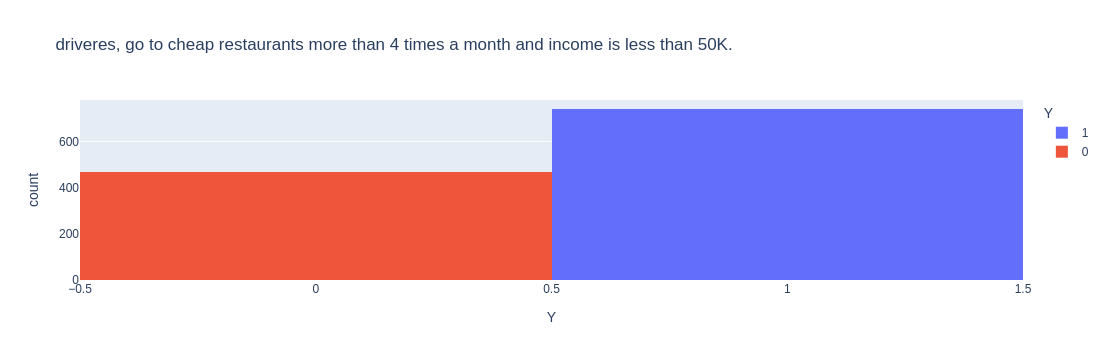

In [335]:
fig = px.histogram(crg4_il50K_df, x="Y", color="Y", title="driveres, go to cheap restaurants more than 4 times a month and income is less than 50K.")                
fig.show()
fig.write_image("images/drivers_cheap_more_than_four_income_less_50.png")

In [336]:
crg4_il50K_len = len(crg4_il50K_df)
crg4_il50K_len

1208

In [337]:
crg4_il50K_Y_df = crg4_il50K_df[crg4_il50K_df["Y"] == 1]
crg4_il50K_Y_len = len(crg4_il50K_Y_df)
crg4_il50K_Y_len

740

In [338]:
crg4_il50K_Y_len/crg4_il50K_len

0.6125827814569537

#### Sixty-one percent of drivers who do to less than 20 dollar restaurants, more than 4 times a month, and make less than 50K use coupons.

### 7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Sixty-nine percent of the population who go more than once a month, have passengers that are not kids chose to use coupons. There are no Farming, Passengers with no kids were Friends are a partner.  Frequency and coming with other increase the chances. 

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

### 20 to 50 Restaurant

In [339]:
rest_20to50_df = data[data['Restaurant20To50'] == 'gt8']
rest_20to50_len = len(rest_20to50_df)
rest_20to50_len

264

In [340]:
def yes_coupon(df):
    return df[df['Y'] == 1]

In [341]:
rest_20to50_Y_df = yes_coupon(rest_20to50_df)
len(rest_20to50_Y_df)

175

In [342]:
def ratio(df1,df2):
    print(f"{len(df1)} / {len(df2)}")
    return len(df1)/len(df2)

In [343]:
ratio(rest_20to50_Y_df,rest_20to50_df)

175 / 264


0.6628787878787878

In [344]:
data['age'].unique()

<ArrowStringArray>
['21', '46', '26', '31', '41', '50plus', '36', 'below21']
Length: 8, dtype: str

In [345]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"] == 'Kid(s)']
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

6 / 11


0.5454545454545454

In [346]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Friend(s)"])] # 69% with Friends
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

63 / 91


0.6923076923076923

In [347]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Partner"])]
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

5 / 8


0.625

In [348]:
rest_20to50_kids_df = rest_20to50_df[rest_20to50_df["passanger"].isin(["Alone"])]
rest_20to50_kids_Y_df = yes_coupon(rest_20to50_kids_df)
ratio(rest_20to50_kids_Y_df,rest_20to50_kids_df)

101 / 154


0.6558441558441559

In [349]:
data["passanger"].unique()

<ArrowStringArray>
['Alone', 'Friend(s)', 'Kid(s)', 'Partner']
Length: 4, dtype: str

In [350]:
fifty_plus_df = data[data['age'] == '50plus']
fifty_plus_Y_df = yes_coupon(fifty_plus_df)
ratio(fifty_plus_Y_df, fifty_plus_df)

910 / 1788


0.5089485458612976

In [351]:
fifty_plus_friends_df = fifty_plus_df[fifty_plus_df["passanger"].isin(["Friend(s)"])] # having friends increases by 9 percent!
fifty_plus_friends_Y_df = yes_coupon(fifty_plus_friends_df)
ratio(fifty_plus_friends_Y_df,fifty_plus_friends_df)

280 / 473


0.5919661733615222

In [352]:
fifty_plus_friends_df = fifty_plus_df[fifty_plus_df["passanger"].isin(["Friend(s)"])] # having friends increases by 9 percent!
fifty_plus_friends_Y_df = yes_coupon(fifty_plus_friends_df)
ratio(fifty_plus_friends_Y_df,fifty_plus_friends_df)

280 / 473


0.5919661733615222

In [353]:
twenty_one_df = data[data['age'].isin(["21"])]
twenty_one_Y_df = yes_coupon(twenty_one_df)
ratio(twenty_one_Y_df, twenty_one_df)

1587 / 2653


0.5981907274783265

In [354]:
twenty_one_friends_df = twenty_one_df[twenty_one_df["passanger"].isin(["Friend(s)"])] # having friends increases by 10 percent!
twenty_one_friends_Y_df = yes_coupon(twenty_one_friends_df)
ratio(twenty_one_friends_Y_df,twenty_one_friends_df)

513 / 736


0.6970108695652174

In [355]:
twenty_one_friends_df = twenty_one_df[twenty_one_df["passanger"].isin(["Alone"])] # having friends increases by 10 percent!
twenty_one_friends_Y_df = yes_coupon(twenty_one_friends_df)
ratio(twenty_one_friends_Y_df,twenty_one_friends_df)

875 / 1595


0.54858934169279

In [356]:
young_df = data[data['age'].isin(["21", "26", "31"])]
young_Y_df = yes_coupon(young_df)
ratio(young_Y_df, young_df)

4226 / 7251


0.5828161632878224

In [357]:
young_friends_df = young_df[young_df["passanger"].isin(["Friend(s)"])] # having friends increases by 11 percent!
young_friends_Y_df = yes_coupon(young_friends_df)
ratio(young_friends_Y_df,young_friends_df)

1332 / 1906


0.6988457502623295

In [358]:
young_friends_df = young_df[young_df["passanger"].isin(["Alone"])] # having friends increases by 11 percent!
young_friends_Y_df = yes_coupon(young_friends_df)
ratio(young_friends_Y_df,young_friends_df)

2266 / 4240


0.534433962264151